In [14]:
import torch
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam
from torchvision import transforms
from copy import deepcopy

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

import sqlite3
import pandas as pd

import subprocess
from datetime import datetime

from pathlib import Path
import sys

ROOT = Path.cwd().parents[1]
sys.path.append(str(ROOT))

from src.config.paths import EMBEDS_DIR, RESULTS, DB_PATH, MODEL_DIR
EMBED_PATH = EMBEDS_DIR/ "cont_embeds.pt"
EMBED_NAME = EMBED_PATH.stem

RESULTS_DIR = RESULTS / EMBED_NAME

In [15]:
contrastive_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [16]:
conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query("""
    SELECT path, split
    FROM meta
""", conn)

categories = pd.read_sql_query("SELECT DISTINCT category FROM meta", conn)["category"].to_list()

conn.close()

train_paths = df[df["split"] == "train"]["path"].to_list()
test_paths = df[df["split"] != "train"]["path"].to_list()

In [17]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

2.12.0+cu130
13.0
True
1


In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {device}")

Device: cuda


In [19]:
dino = torch.hub.load(
            "facebookresearch/dinov2",
            "dinov2_vits14"
        )

dino.to(device)
dino.eval()

for p in dino.parameters():
    p.requires_grad = False

Using cache found in /home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main


In [ ]:
%load_ext autoreload
%autoreload 2

from src.fine_tune import ModelData, ProjectionHead, BatchSampler, train_one_epoch, evaluate

from src.fine_tune.losses.combined_loss import CombinedLoss

git_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    text=True
).strip()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
LOSSES = {
    "category_cont" : True,
    "preservation": True
}

WEIGHTS = {
    "category_cont" : 1.0,
    "preservation": 0.5
}

NOTES = [
    "Doubled the hidden dimension to 768"
]

In [ ]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

SEED = 42

NUM_WORKERS = 8
PIN_MEMORY = device == "cuda"
SAMPLES_PER_CATEGORY = 16

BATCH_SIZE = len(categories) * SAMPLES_PER_CATEGORY

EPOCHS = 20

DIM = 384
HIDDEN_DIM = 768

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

MODEL_NAME = f"{timestamp}_combined_loss_model.pt"

In [ ]:
MODEL_INFO = {
    "losses" : LOSSES,
    "weights" : WEIGHTS,
    "notes" : NOTES,
    "git_commit" : git_commit,
    "parameters" : {
        "batch_size" : 256,
        "epochs" : EPOCHS,
        "samples_per_category" : SAMPLES_PER_CATEGORY,

        "model_dim" : DIM,
        "hidden_dim": HIDDEN_DIM,

        "learning_rate" : LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        
        "num_workers" : NUM_WORKERS,
        "pin_memory" : PIN_MEMORY,

        "random_seed" : SEED
    }
}

In [ ]:
category_to_id = {category: idx for idx, category in enumerate(categories)}

dataset = ModelData(train_paths, root=ROOT, category_to_id=category_to_id, transform=contrastive_transform)
test_set = ModelData(test_paths, root=ROOT, category_to_id=category_to_id, transform=test_transform)

train_split = int(len(dataset) * 0.95)
val_split = len(dataset) - train_split

generator = torch.Generator().manual_seed(SEED)

train_set, val_set = random_split(
    dataset,
    [train_split, val_split],
    generator=generator
)

train_labels = [dataset.labels[i] for i in train_set.indices]
val_labels = [dataset.labels[i] for i in val_set.indices]

train_sampler = BatchSampler(
    labels=train_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=None
)

val_sampler = BatchSampler(
    labels=val_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=SEED
)

train_loader = DataLoader(
    train_set,
    batch_sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_set,
    batch_sampler=val_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [ ]:
model = ProjectionHead(dim=DIM, hidden_dim=HIDDEN_DIM).to(device)

optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = CombinedLoss(enabled=LOSSES, weights=WEIGHTS)

In [ ]:

results = pd.DataFrame(columns=["epoch", "train_loss", "val_loss", "gap"])

best_val = float("inf")
best_state = None

try:
    for epoch in tqdm(range(EPOCHS)):
        train_loss = train_one_epoch(model, dino, train_loader, criterion, optimizer, device)
        val_loss = evaluate(model, dino, val_loader, criterion, device)

        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())
            
        results.loc[len(results)] = {
            "epoch": epoch+1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "gap": abs(val_loss - train_loss)
        }
        
        print(results.tail(1).to_string(
            index=False,
            header=(epoch==0)
        ) + "\n")

finally:
    if best_state is not None:
        checkpoint = {
            "model_state_dict" : best_state,
            "model_info" : MODEL_INFO
        }
        torch.save(checkpoint, MODEL_DIR / MODEL_NAME)
        print(f"Best Model Saved (val_loss={best_val:.4f})")

  0%|          | 0/20 [00:00<?, ?it/s]

same=0.8439, different=0.2992, gap=0.5447
Gradient Norm: 1.144873391068513
Paramter change: 0.000999912852421403
same=0.8781, different=0.1010, gap=0.7772
Gradient Norm: 0.4470259791015159
Paramter change: 0.0006916324491612613
same=0.9287, different=0.0598, gap=0.8688
Gradient Norm: 0.17979639300078296
Paramter change: 0.0005649105878546834
same=0.9456, different=0.0589, gap=0.8867
Gradient Norm: 0.1620242086131026
Paramter change: 0.0004818368761334568
same=0.9605, different=0.0675, gap=0.8930
Gradient Norm: 0.080105071622055
Paramter change: 0.00041536972275935113
same=0.9673, different=0.0672, gap=0.9000
Gradient Norm: 0.06968535365013116
Paramter change: 0.0003664805553853512
same=0.9712, different=0.0834, gap=0.8878
Gradient Norm: 0.07551477291692184
Paramter change: 0.00032706151250749826
same=0.9744, different=0.0865, gap=0.8880
Gradient Norm: 0.0504671839450681
Paramter change: 0.00029538391390815377
same=0.9774, different=0.0819, gap=0.8955
Gradient Norm: 0.058528616288006555

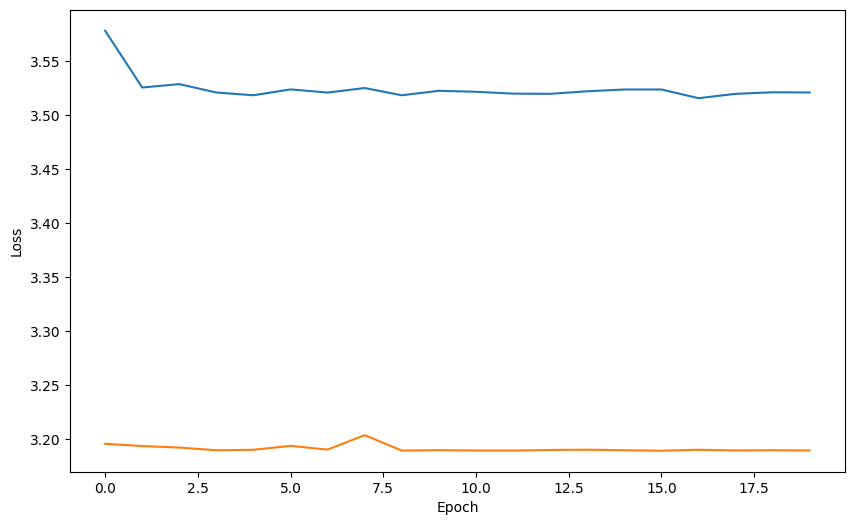

In [ ]:
fig = plt.figure(figsize=(10, 6))

plt.plot(range(EPOCHS), results["train_loss"])
plt.plot(range(EPOCHS), results["val_loss"])

plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.show()